# Análisis Exploratorio de Datos (EDA)
## Detección de voz sintética con el dataset Fake-or-Real (FoR)

Se utilizó el dataset Fake-or-Real (FoR), el cual contiene aproximadamente 195,000 audios de voz real y sintética generados mediante modelos de síntesis de voz como WaveNet y Deep Voice 3. En este proyecto se empleó la versión for-norm, ya que los audios se encuentran balanceados y normalizados, facilitando el entrenamiento de modelos de Machine Learning.

Enlace de Dataset: https://www.kaggle.com/datasets/mohammedabdeldayem/the-fake-or-real-dataset

Este notebook realiza un análisis exploratorio inicial del dataset **Fake-or-Real (FoR)** para estudiar diferencias entre audios **reales** y **sintéticos**. El objetivo es identificar características útiles para modelos como **Random Forest** y **CNN**.

## 1. Librerías


In [1]:
!pip install numpy pandas matplotlib librosa scikit-learn tensorflow

In [2]:
import os
from glob import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display

plt.rcParams['figure.figsize'] = (10, 4)

## 2. Configuración de rutas

In [13]:
REAL_PATH = 'archive (3)/for-norm/for-norm/training/real/*.wav'
FAKE_PATH = 'archive (3)/for-norm/for-norm/training/fake/*.wav'

real_files = glob(REAL_PATH)
fake_files = glob(FAKE_PATH)

print('Cantidad de audios reales:', len(real_files))
print('Cantidad de audios falsos:', len(fake_files))


Cantidad de audios reales: 26941
Cantidad de audios falsos: 26927


## 3. Distribución de clases

Verificamos si el dataset está balanceado entre las clases **real** y **fake**.


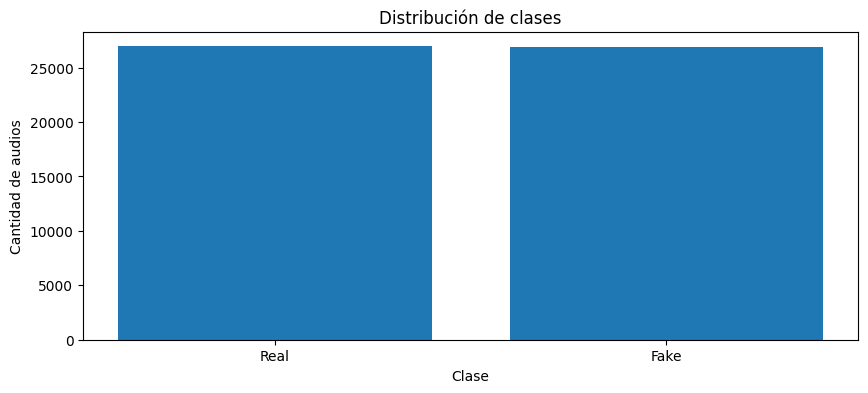

In [14]:
labels = ['Real', 'Fake']
values = [len(real_files), len(fake_files)]

plt.figure()
plt.bar(labels, values)
plt.title('Distribución de clases')
plt.xlabel('Clase')
plt.ylabel('Cantidad de audios')
plt.show()


## 4. Funciones auxiliares


In [15]:
def cargar_audio(file_path):
    audio, sr = librosa.load(file_path, sr=None)
    return audio, sr

def obtener_duracion(files, n=500):
    duraciones = []
    for f in files[:n]:
        try:
            audio, sr = librosa.load(f, sr=None)
            duraciones.append(len(audio) / sr)
        except Exception as e:
            print(f'Error procesando {f}: {e}')
    return duraciones

def extraer_features_basicas(file_path):
    audio, sr = librosa.load(file_path, sr=None)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
    zcr = librosa.feature.zero_crossing_rate(audio)
    spectral_centroid = librosa.feature.spectral_centroid(y=audio, sr=sr)
    rms = librosa.feature.rms(y=audio)

    return {
        'duracion': len(audio) / sr,
        'sample_rate': sr,
        'mfcc_mean': float(np.mean(mfcc)),
        'mfcc_std': float(np.std(mfcc)),
        'zcr_mean': float(np.mean(zcr)),
        'spectral_centroid_mean': float(np.mean(spectral_centroid)),
        'rms_mean': float(np.mean(rms)),
    }


## 5. Duración de los audios

Analizamos la distribución de duración de una muestra de audios reales y falsos.


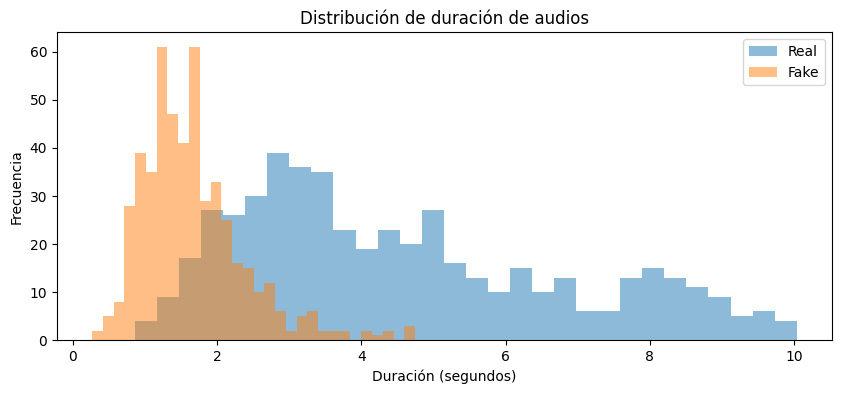

Duración promedio real: 4.5408045
Duración promedio fake: 1.6607394999999998


In [16]:
dur_real = obtener_duracion(real_files, n=500)
dur_fake = obtener_duracion(fake_files, n=500)

plt.figure()
plt.hist(dur_real, alpha=0.5, label='Real', bins=30)
plt.hist(dur_fake, alpha=0.5, label='Fake', bins=30)
plt.legend()
plt.title('Distribución de duración de audios')
plt.xlabel('Duración (segundos)')
plt.ylabel('Frecuencia')
plt.show()

print('Duración promedio real:', np.mean(dur_real) if dur_real else 'N/A')
print('Duración promedio fake:', np.mean(dur_fake) if dur_fake else 'N/A')


## 6. Frecuencia de muestreo

Verificamos la frecuencia de muestreo de algunos archivos para confirmar consistencia.


In [17]:
sample_rates = []
for f in (real_files[:10] + fake_files[:10]):
    try:
        _, sr = librosa.load(f, sr=None)
        sample_rates.append(sr)
    except Exception as e:
        print(f'Error leyendo {f}: {e}')

print('Frecuencias de muestreo encontradas:', sorted(set(sample_rates)))


Frecuencias de muestreo encontradas: [16000]


## 7. Visualización de forma de onda

Comparamos un ejemplo de audio real y uno falso.


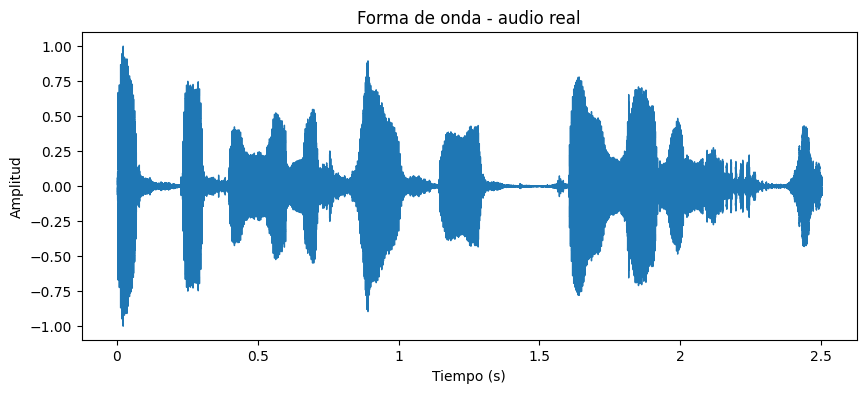

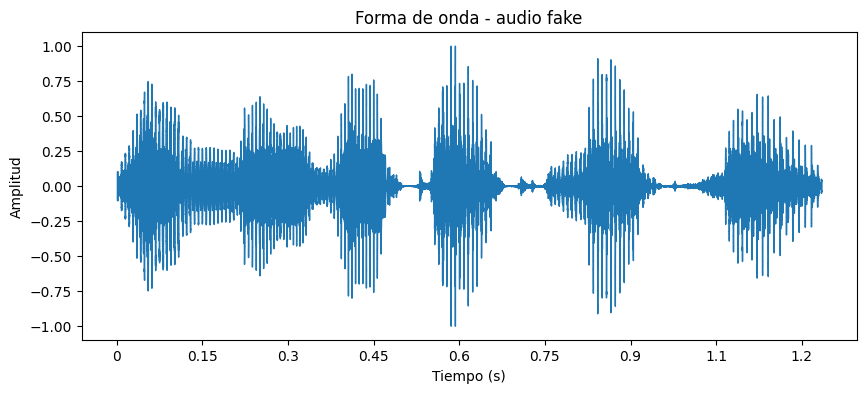

In [18]:
if real_files:
    audio_real, sr_real = cargar_audio(real_files[0])
    plt.figure()
    librosa.display.waveshow(audio_real, sr=sr_real)
    plt.title('Forma de onda - audio real')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud')
    plt.show()

if fake_files:
    audio_fake, sr_fake = cargar_audio(fake_files[0])
    plt.figure()
    librosa.display.waveshow(audio_fake, sr=sr_fake)
    plt.title('Forma de onda - audio fake')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud')
    plt.show()


## 8. Espectrograma Mel

Los espectrogramas Mel son especialmente útiles para modelos CNN.


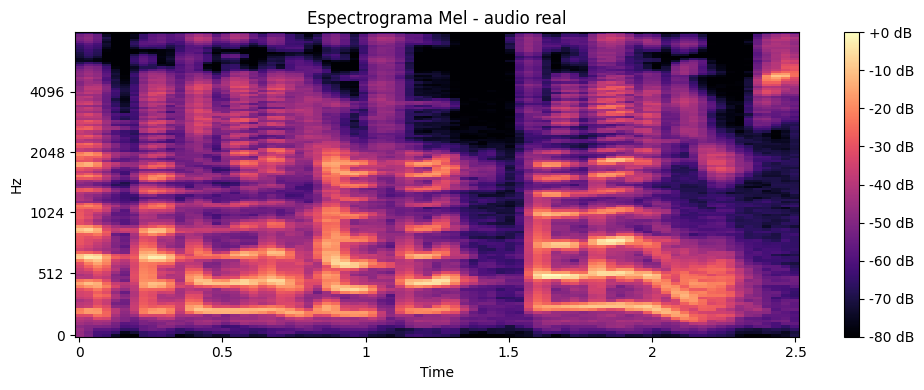

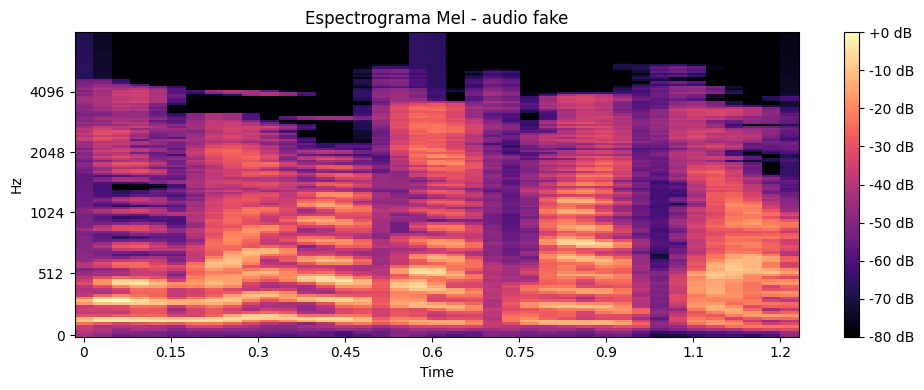

In [19]:
if real_files:
    audio_real, sr_real = cargar_audio(real_files[0])
    mel_real = librosa.feature.melspectrogram(y=audio_real, sr=sr_real)
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(librosa.power_to_db(mel_real, ref=np.max), sr=sr_real, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title('Espectrograma Mel - audio real')
    plt.tight_layout()
    plt.show()

if fake_files:
    audio_fake, sr_fake = cargar_audio(fake_files[0])
    mel_fake = librosa.feature.melspectrogram(y=audio_fake, sr=sr_fake)
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(librosa.power_to_db(mel_fake, ref=np.max), sr=sr_fake, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title('Espectrograma Mel - audio fake')
    plt.tight_layout()
    plt.show()


## 9. Extracción de características acústicas básicas

Construimos una tabla simple con algunas features útiles para el modelo Random Forest.


In [20]:
muestra_real = real_files[:100]
muestra_fake = fake_files[:100]

rows = []

for f in muestra_real:
    try:
        feats = extraer_features_basicas(f)
        feats['label'] = 'real'
        feats['file'] = os.path.basename(f)
        rows.append(feats)
    except Exception as e:
        print(f'Error real {f}: {e}')

for f in muestra_fake:
    try:
        feats = extraer_features_basicas(f)
        feats['label'] = 'fake'
        feats['file'] = os.path.basename(f)
        rows.append(feats)
    except Exception as e:
        print(f'Error fake {f}: {e}')

df_features = pd.DataFrame(rows)
df_features.head()


,duracion,sample_rate,mfcc_mean,mfcc_std,zcr_mean,spectral_centroid_mean,rms_mean,label,file
0,2.501625,16000,-20.664412,71.900574,0.137460,1822.402563,0.126172,real,file1.wav_16k.wav_norm.wav_mono.wav_silence.wav
1,3.903625,16000,-3.597677,63.565666,0.154065,1768.520360,0.133983,real,file10.wav_16k.wav_norm.wav_mono.wav_silence.wav
2,3.491062,16000,-2.998511,78.645912,0.095206,1446.031905,0.131446,real,file100.wav_16k.wav_norm.wav_mono.wav_silence.wav
3,9.532187,16000,-24.814701,81.944817,0.188090,2033.304687,0.083413,real,file1000.wav_16k.wav_norm.wav_mono.wav_silence...
4,4.185125,16000,-21.590662,67.368881,0.193106,2081.626495,0.129482,real,file10000.wav_16k.wav_norm.wav_mono.wav_silenc...


## 10. Estadísticas descriptivas


In [21]:
df_features.groupby('label').mean(numeric_only=True)


,duracion,sample_rate,mfcc_mean,mfcc_std,zcr_mean,spectral_centroid_mean,rms_mean
label,,,,,,,
fake,1.570378,16000.0,-10.567688,68.723092,0.127723,1549.212105,0.159743
real,4.683139,16000.0,-13.506710,70.327659,0.149126,1880.657280,0.117095


## 11. Comparación visual de features


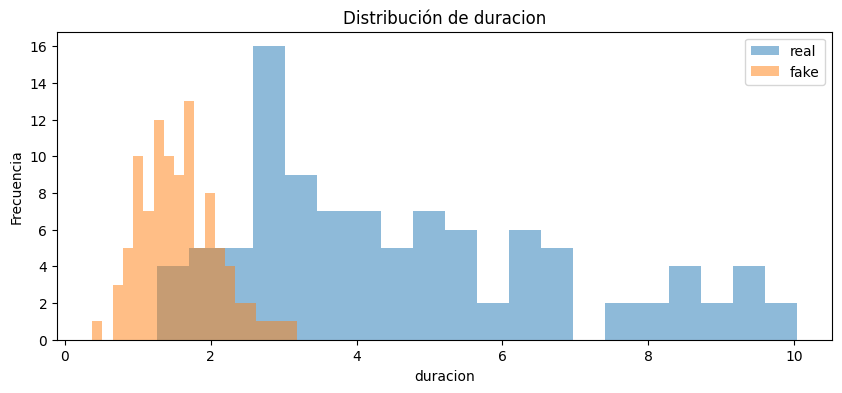

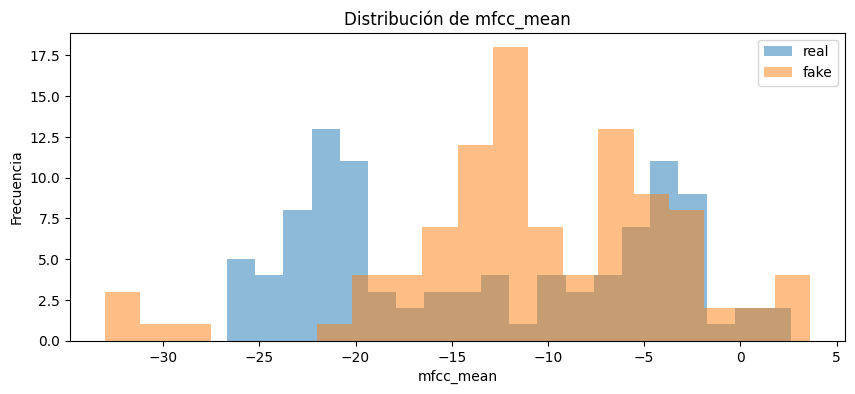

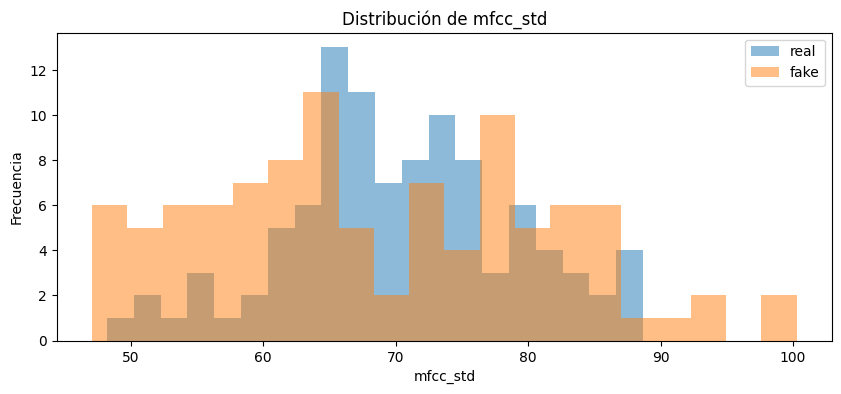

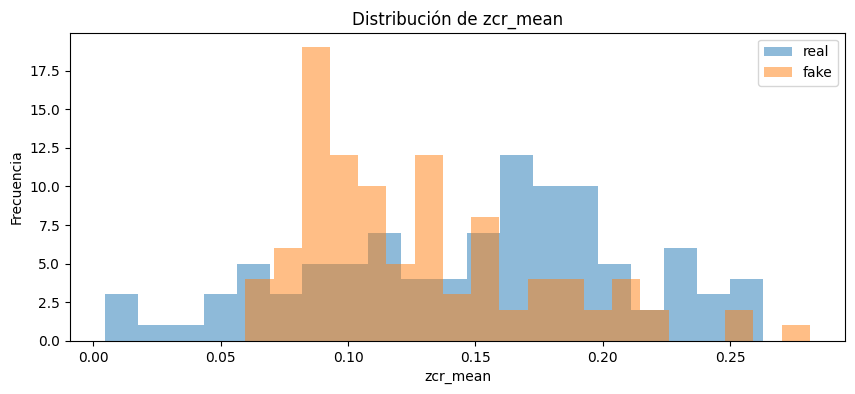

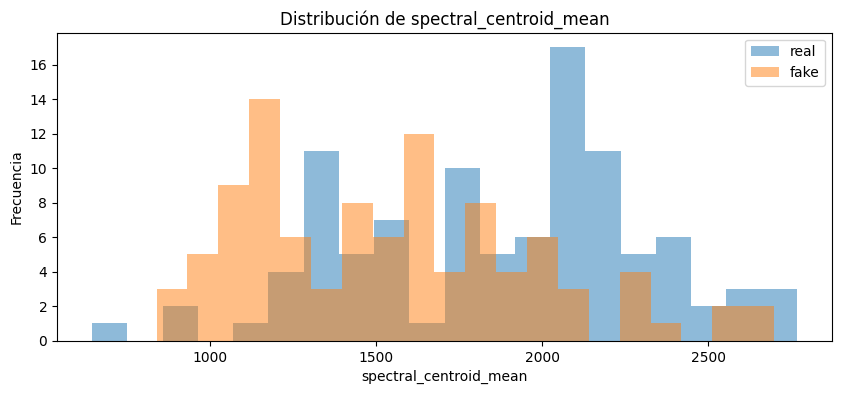

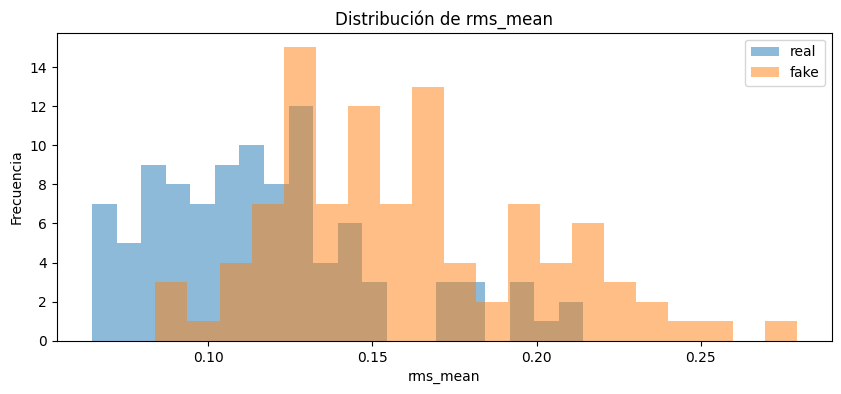

In [22]:
features_to_plot = ['duracion', 'mfcc_mean', 'mfcc_std', 'zcr_mean', 'spectral_centroid_mean', 'rms_mean']

for feature in features_to_plot:
    plt.figure()
    for label in ['real', 'fake']:
        subset = df_features[df_features['label'] == label][feature]
        plt.hist(subset, alpha=0.5, label=label, bins=20)
    plt.title(f'Distribución de {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frecuencia')
    plt.legend()
    plt.show()


## 12. Hallazgos preliminares


El análisis exploratorio del dataset Fake-or-Real (FoR) mostró que las clases de audios reales y sintéticos se encuentran balanceadas, lo cual favorece el entrenamiento del modelo. Se observaron ligeras diferencias en la forma de onda y en los espectrogramas, donde la voz sintética presenta patrones más uniformes en ciertas frecuencias.

Las características acústicas extraídas, como MFCC, zero crossing rate y energía de la señal, evidencian variaciones entre ambas clases, indicando que contienen información útil para la clasificación.

Estos resultados sugieren que es posible utilizar tanto Random Forest con features acústicas como CNN con espectrogramas para detectar deepfakes de voz.